# Part II Evaluations (+ F: method comparison + H)

# Further evaluations 
**Responsible:** 

3.6.1 Settings and Protocol _(Joao, F)_

3.6.2 Base Heuristics _(Joao, A)_

3.6.3 Batch Allocation _(Cam, B)_

3.6.4 Kunkler Formalization _(Thomas, C)_

3.6.5 Park Formalization _(Joao, C)_

Placeholder
...

## RL policy evaluation
**Responsible:**  _(Aldo Patrone)_

The RL policy is evaluated at two levels. First a fast controlled case-based environment (arrival rate and case length matched to the real BPIC-17 log) for method development, scored on the disclosed equal-weight objective (cycle time + fairness, lower is better). Baselines: random, round-robin, shortest-queue, experience-greedy. The learned agents trade cycle time against fairness, but shortest-queue already matches them, since load-balancing serves fairness directly. The reward was aligned to the objective but not tuned to this score.

The robust verdict comes from the integrated simulator across multiple seeds (below).

          method  cycle_time_h  load_gini  combined
          random          0.98      0.471     0.821
     round-robin          1.12      0.477     0.886
  shortest-queue          1.07      0.486     0.872
most-experienced          1.16      0.591     1.000
  RL (REINFORCE)          0.91      0.542     0.851


saved ../results/allocation_comparison.png


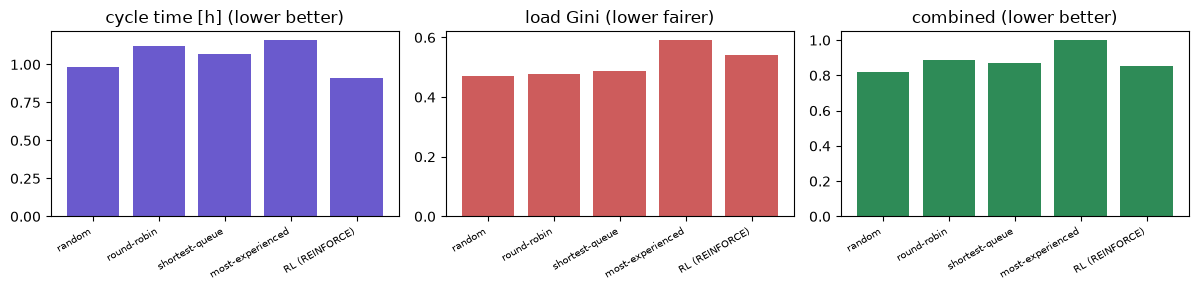

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
cmp = pd.read_csv('../results/allocation_comparison.csv')
print(cmp.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].bar(cmp['method'], cmp['cycle_time_h'], color='slateblue')
axes[0].set_title('cycle time [h] (lower better)')
axes[1].bar(cmp['method'], cmp['load_gini'], color='indianred')
axes[1].set_title('load Gini (lower fairer)')
axes[2].bar(cmp['method'], cmp['combined'], color='seagreen')
axes[2].set_title('combined (lower better)')
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
    for lbl in ax.get_xticklabels():
        lbl.set_ha('right'); lbl.set_fontsize(7)
fig.tight_layout(); fig.savefig('../results/allocation_comparison.png', dpi=120)
print('saved ../results/allocation_comparison.png')

## RL policy on the integrated simulator (multi-seed)
**Responsible:**  _(Aldo Patrone)_

Every method runs through the identical integrated simulation engine and is scored by compute_all, over five random seeds under a congested load. This is the robust test.

Naming: in this multi-seed run the RL slot loaded the simulator-trained PPO policy, so its row is renamed to PPO on simulator in the aggregation below. The comparison therefore holds two deep-learning variants, MaskablePPO trained on the surrogate environment and PPO trained on the simulator itself.

Honest finding: no deep-learning variant beats shortest-queue. The fairness Gini is a statistical tie across all methods (about 0.58), while shortest-queue clearly leads resource occupation (0.77 against roughly 0.54 to 0.65). Average cycle time was 0.3 days for every method, so allocation barely moves it.

The negative result is robust, not an artifact of weak training. The obvious counter-explanations were each closed: the load feature was aligned between training and inference, the fairness signal was made scale-invariant, the policy was trained directly on the simulator (sim-in-the-loop), MaskablePPO was included and a PPO learner was trained on the simulator warm-started from the surrogate policy (the faithful Middelhuis setup). shortest-queue is near-optimal for the load-Gini fairness metric, so a learned policy is not justified for this objective. The full cross-method synthesis of all group methods is task F (3.6.7).

                  fairness_gini        occupation       
                           mean    std       mean    std
method                                                  
shortest-queue            0.582  0.024      0.772  0.058
random                    0.581  0.017      0.647  0.096
most-experienced          0.614  0.010      0.540  0.037
PPO (MaskablePPO)         0.576  0.015      0.567  0.049
PPO on simulator          0.584  0.023      0.538  0.046
saved ../results/allocation_sim_comparison.png


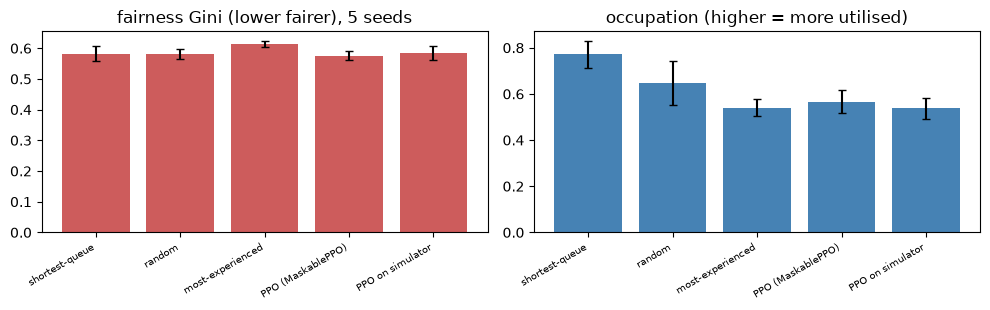

In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

seeds = range(1, 6)
alld = pd.concat([pd.read_csv(f'../results/ms_seed{s}.csv') for s in seeds])
alld['method'] = alld['method'].replace({'RL (REINFORCE)': 'PPO on simulator'})
agg = alld.groupby('method')[['fairness_gini', 'occupation']].agg(['mean', 'std'])
order = ['shortest-queue', 'random', 'most-experienced', 'PPO (MaskablePPO)', 'PPO on simulator']
agg = agg.reindex(order)
print(agg.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].bar(order, agg[('fairness_gini', 'mean')], yerr=agg[('fairness_gini', 'std')], color='indianred', capsize=3)
axes[0].set_title('fairness Gini (lower fairer), 5 seeds')
axes[1].bar(order, agg[('occupation', 'mean')], yerr=agg[('occupation', 'std')], color='steelblue', capsize=3)
axes[1].set_title('occupation (higher = more utilised)')
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
    for lbl in ax.get_xticklabels():
        lbl.set_ha('right'); lbl.set_fontsize(7)
fig.tight_layout(); fig.savefig('../results/allocation_sim_comparison.png', dpi=120)
print('saved ../results/allocation_sim_comparison.png')

# Further evaluations 
**Responsible:** 

3.6.7 Cross-Method Synthesis _(Joao, F)_

3.6.8 Slide-23 Question _(Cam, H)_

Placeholder
...